In [ ]:
!pip install -q qiskit qiskit-aer pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

from qiskit_aer import AerSimulator

from qiskit.visualization import (
    plot_histogram,
    plot_state_city
)

print("Qiskit imported successfully!")

Qiskit imported successfully!


CNOT Circuit:


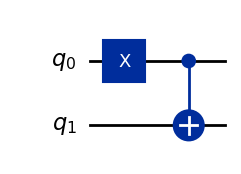


Final Statevector:
[0.+0.j 0.+0.j 0.+0.j 1.+0.j]


In [ ]:
# ==========================================
# EASY: CNOT GATE
# ==========================================

# Create a 2-qubit circuit
qc_cnot = QuantumCircuit(2)

# Put control qubit q0 into |1>
qc_cnot.x(0)

# Apply CNOT
# q0 = control
# q1 = target
qc_cnot.cx(0, 1)

print("CNOT Circuit:")
display(qc_cnot.draw("mpl"))

# Get final statevector
state_cnot = Statevector.from_instruction(qc_cnot)

print("\nFinal Statevector:")
print(state_cnot.data)

Measurement Circuit:


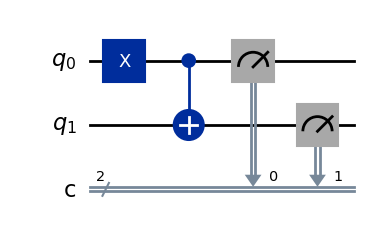


Measurement Results:
{'11': 1024}


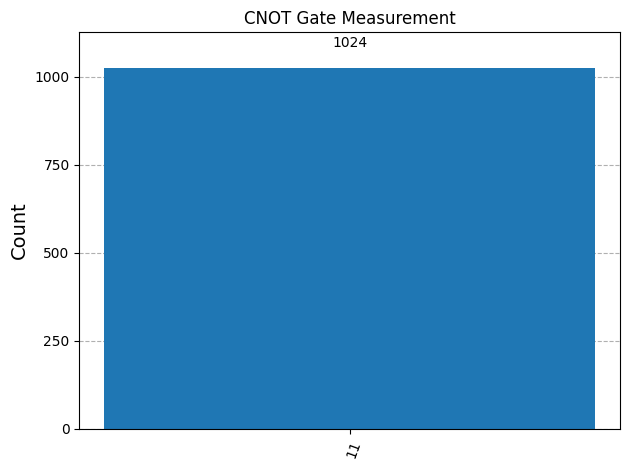

In [ ]:
# ==========================================
# CNOT MEASUREMENT
# ==========================================

qc_cnot_measure = QuantumCircuit(2, 2)

# Control = |1>
qc_cnot_measure.x(0)

# CNOT
qc_cnot_measure.cx(0, 1)

# Measure both qubits
qc_cnot_measure.measure([0, 1], [0, 1])

print("Measurement Circuit:")
display(qc_cnot_measure.draw("mpl"))

simulator = AerSimulator()

result = simulator.run(
    qc_cnot_measure,
    shots=1024
).result()

counts_cnot = result.get_counts()

print("\nMeasurement Results:")
print(counts_cnot)

display(
    plot_histogram(
        counts_cnot,
        title="CNOT Gate Measurement"
    )
)

Bell State Circuit:


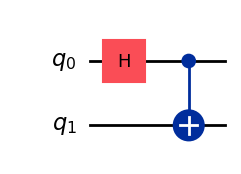


Bell Statevector:
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


In [ ]:
# ==========================================
# MEDIUM: BELL STATE
# ==========================================

qc_bell = QuantumCircuit(2)

# Step 1: Hadamard on first qubit
qc_bell.h(0)

# Step 2: CNOT
qc_bell.cx(0, 1)

print("Bell State Circuit:")
display(qc_bell.draw("mpl"))

# Get statevector
state_bell = Statevector.from_instruction(qc_bell)

print("\nBell Statevector:")
print(state_bell.data)

Bell Measurement Circuit:


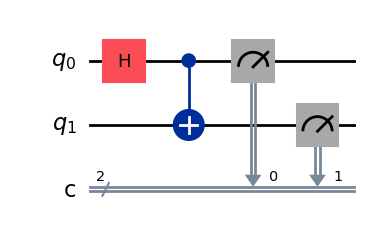


Measurement Results:
{'11': 529, '00': 495}


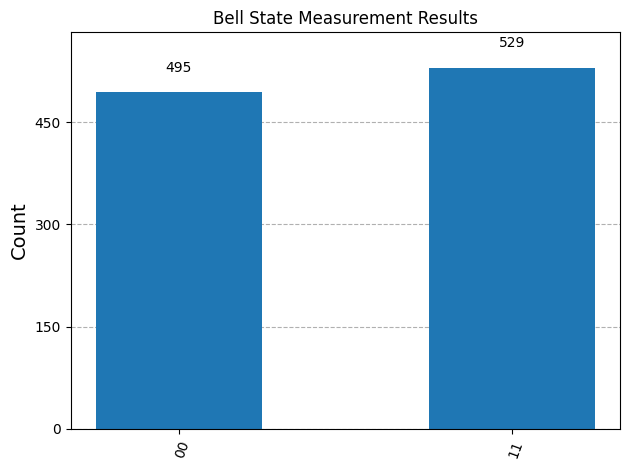

In [ ]:
# ==========================================
# BELL STATE MEASUREMENT
# ==========================================

qc_bell_measure = QuantumCircuit(2, 2)

qc_bell_measure.h(0)
qc_bell_measure.cx(0, 1)

qc_bell_measure.measure([0, 1], [0, 1])

print("Bell Measurement Circuit:")
display(qc_bell_measure.draw("mpl"))

result = simulator.run(
    qc_bell_measure,
    shots=1024
).result()

counts_bell = result.get_counts()

print("\nMeasurement Results:")
print(counts_bell)

display(
    plot_histogram(
        counts_bell,
        title="Bell State Measurement Results"
    )
)

GHZ State Circuit:


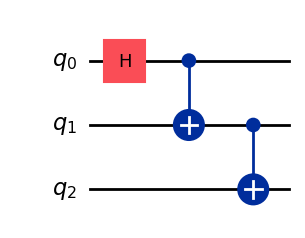


GHZ Statevector:
[0.70710678+0.j 0.        +0.j 0.        +0.j 0.        +0.j
 0.        +0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


In [ ]:
# ==========================================
# HARD: 3-QUBIT GHZ STATE
# ==========================================

qc_ghz = QuantumCircuit(3)

# Create superposition
qc_ghz.h(0)

# Entangle q0 with q1
qc_ghz.cx(0, 1)

# Entangle q1 with q2
qc_ghz.cx(1, 2)

print("GHZ State Circuit:")
display(qc_ghz.draw("mpl"))

# Statevector
state_ghz = Statevector.from_instruction(qc_ghz)

print("\nGHZ Statevector:")
print(state_ghz.data)

GHZ Measurement Circuit:


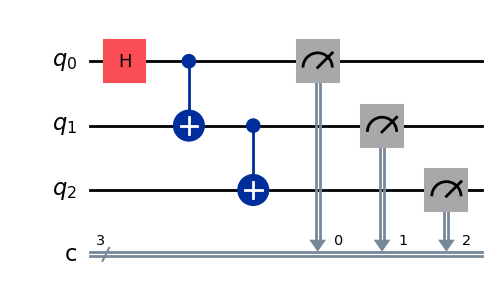


GHZ Measurement Results:
{'111': 466, '000': 558}


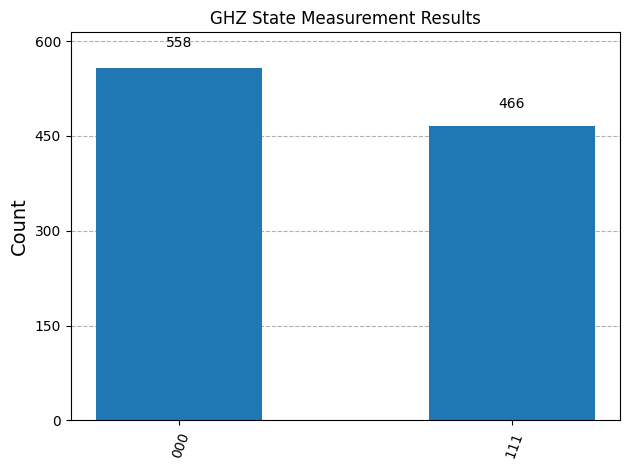

In [ ]:
# ==========================================
# GHZ MEASUREMENT
# ==========================================

qc_ghz_measure = QuantumCircuit(3, 3)

qc_ghz_measure.h(0)

qc_ghz_measure.cx(0, 1)

qc_ghz_measure.cx(1, 2)

qc_ghz_measure.measure(
    [0, 1, 2],
    [0, 1, 2]
)

print("GHZ Measurement Circuit:")
display(qc_ghz_measure.draw("mpl"))

result = simulator.run(
    qc_ghz_measure,
    shots=1024
).result()

counts_ghz = result.get_counts()

print("\nGHZ Measurement Results:")
print(counts_ghz)

display(
    plot_histogram(
        counts_ghz,
        title="GHZ State Measurement Results"
    )
)

In [ ]:
# ==========================================
# REAL WORLD: FULL ADDER
# ==========================================

def full_adder_circuit(A, B, Cin):

    # 5 qubits
    # q0 = A
    # q1 = B
    # q2 = Cin
    # q3 = Sum
    # q4 = Carry

    qc = QuantumCircuit(5, 2)

    # --------------------------------------
    # Set input values
    # --------------------------------------

    if A == 1:
        qc.x(0)

    if B == 1:
        qc.x(1)

    if Cin == 1:
        qc.x(2)

    # --------------------------------------
    # SUM = A XOR B XOR Cin
    # --------------------------------------

    qc.cx(0, 3)
    qc.cx(1, 3)
    qc.cx(2, 3)

    # --------------------------------------
    # CARRY
    # Carry = AB XOR Cin(A XOR B)
    # --------------------------------------

    # AB
    qc.ccx(0, 1, 4)

    # A XOR B -> temporary control
    qc.cx(0, 1)

    # Cin AND (A XOR B)
    qc.ccx(2, 1, 4)

    # Restore B
    qc.cx(0, 1)

    # --------------------------------------
    # Measure Sum and Carry
    # --------------------------------------

    qc.measure(3, 0)
    qc.measure(4, 1)

    return qc

In [ ]:
# ==========================================
# TEST ALL FULL ADDER INPUTS
# ==========================================

print("FULL ADDER TRUTH TABLE")
print("-" * 45)
print(" A  B  Cin | Sum  Carry")
print("-" * 45)

full_adder_results = []

for A in [0, 1]:

    for B in [0, 1]:

        for Cin in [0, 1]:

            qc = full_adder_circuit(A, B, Cin)

            result = simulator.run(
                qc,
                shots=1
            ).result()

            counts = result.get_counts()

            output = list(counts.keys())[0]

            # Classical bits are displayed as CarrySum
            carry = int(output[0])
            sum_bit = int(output[1])

            print(
                f" {A}  {B}   {Cin}  |  "
                f" {sum_bit}     {carry}"
            )

            full_adder_results.append(
                (A, B, Cin, sum_bit, carry)
            )

FULL ADDER TRUTH TABLE
---------------------------------------------
 A  B  Cin | Sum  Carry
---------------------------------------------
 0  0   0  |   0     0
 0  0   1  |   1     0
 0  1   0  |   1     0
 0  1   1  |   0     1
 1  0   0  |   1     0
 1  0   1  |   0     1
 1  1   0  |   0     1
 1  1   1  |   1     1


Full Adder Circuit for A=1, B=1, Cin=1:


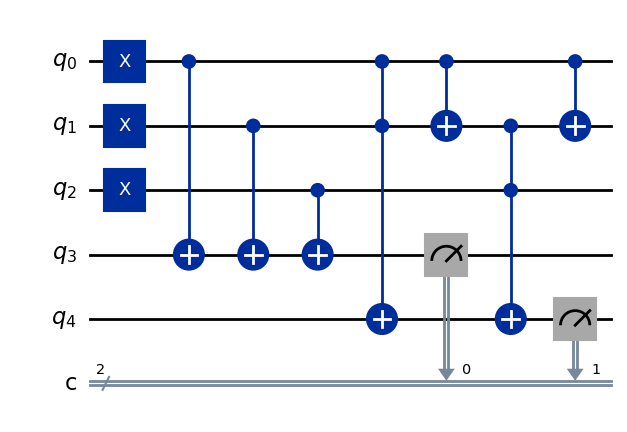


Measurement Result:
{'11': 1024}


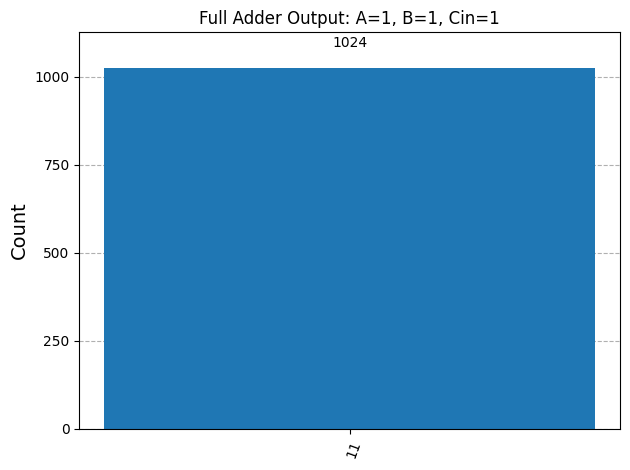

In [ ]:
# ==========================================
# DISPLAY FULL ADDER CIRCUIT
# ==========================================

qc_full = full_adder_circuit(1, 1, 1)

print("Full Adder Circuit for A=1, B=1, Cin=1:")
display(qc_full.draw("mpl"))

result = simulator.run(
    qc_full,
    shots=1024
).result()

counts_full = result.get_counts()

print("\nMeasurement Result:")
print(counts_full)

display(
    plot_histogram(
        counts_full,
        title="Full Adder Output: A=1, B=1, Cin=1"
    )
)

Rotation angle:
1.1592794807274085

Custom Entangled State Circuit:


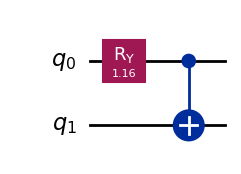


Final Statevector:
[0.83666003+0.j 0.        +0.j 0.        +0.j 0.54772256+0.j]


In [ ]:
# ==========================================
# CHALLENGE: ARBITRARY ENTANGLED STATE
# ==========================================

# Desired probabilities
p00 = 0.7
p11 = 0.3

# Calculate rotation angle
theta = 2 * np.arccos(np.sqrt(p00))

print("Rotation angle:")
print(theta)

# Create circuit
qc_custom = QuantumCircuit(2)

# Create superposition with unequal amplitudes
qc_custom.ry(theta, 0)

# Entangle the qubits
qc_custom.cx(0, 1)

print("\nCustom Entangled State Circuit:")
display(qc_custom.draw("mpl"))

# Statevector
state_custom = Statevector.from_instruction(qc_custom)

print("\nFinal Statevector:")
print(state_custom.data)

In [ ]:
# ==========================================
# VERIFY CUSTOM ENTANGLED STATE
# ==========================================

probabilities = np.abs(state_custom.data) ** 2

print("Statevector probabilities:")
print(probabilities)

print("\nProbability of |00>:")
print(probabilities[0])

print("\nProbability of |11>:")
print(probabilities[3])

Statevector probabilities:
[0.7 0.  0.  0.3]

Probability of |00>:
0.7000000000000001

Probability of |11>:
0.29999999999999993


Measurement Results:
{'00': 716, '11': 308}


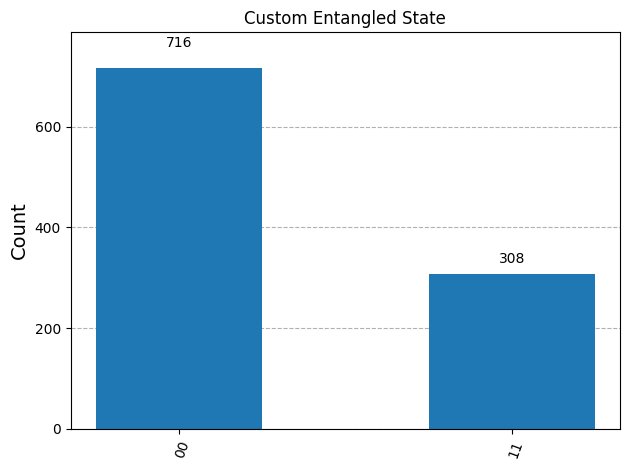

In [ ]:
# ==========================================
# CUSTOM STATE MEASUREMENT
# ==========================================

qc_custom_measure = QuantumCircuit(2, 2)

qc_custom_measure.ry(theta, 0)
qc_custom_measure.cx(0, 1)

qc_custom_measure.measure([0, 1], [0, 1])

result = simulator.run(
    qc_custom_measure,
    shots=1024
).result()

counts_custom = result.get_counts()

print("Measurement Results:")
print(counts_custom)

display(
    plot_histogram(
        counts_custom,
        title="Custom Entangled State"
    )
)